In [118]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns  # a useful plotting library on top of matplotlib
from tqdm.auto import tqdm # a nice progress bar

# # This is a simple example of a diffusion model in 1D.


# generate a dataset of 1D data from a mixture of two Gaussians
# this is a simple example, but you can use any distribution
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set

# we will keep these parameters fixed throughout
# these parameters should give you an acceptable result
# but feel free to play with them
TIME_STEPS = 250
BETA = torch.tensor(0.02)
N_EPOCHS = 1000
BATCH_SIZE = 128
LEARNING_RATE = 0.8e-4

# define the neural network that predicts the amount of noise that was
# added to the data
# the network should have two inputs (the current data and the time step)
# and one output (the predicted noise)

#------------------------------------
g = torch.nn.Sequential(
    torch.nn.Linear(2, 256), # two input params: timestep and current sample value
    torch.nn.ReLU(),
    torch.nn.Linear(256, 256), # simple MLP with two hidden layers
    torch.nn.ReLU(),
    torch.nn.Linear(256, 1) # one output: noise added in timestep t
)

optimizer=torch.optim.Adam(g.parameters(), lr=LEARNING_RATE) # optimizer
loss_function = torch.nn.MSELoss() # MSE loss
betas = torch.full((TIME_STEPS,), BETA) # tensor containing the betas for each timestep
alphas=1.0-betas
alpha_bars=torch.cumprod(alphas, dim=0) # cumulative product of coefficients a
#--------------------

epochs = tqdm(range(N_EPOCHS))  # this makes a nice progress bar
train_loss_hist=[]
val_loss_hist=[]
for e in epochs: # loop over epochs
    g.train()
    # loop through batches of the dataset, reshuffling it each epoch
    indices = torch.randperm(dataset.shape[0])
    shuffled_dataset = dataset[indices]

    #----
    train_loss = 0  # reset train loss
    #---------
    batches = range(0,shuffled_dataset.shape[0]-BATCH_SIZE, BATCH_SIZE)
    for i in batches:
        # sample a batch of data
        x0 = shuffled_dataset[i:i + BATCH_SIZE] #step 2

        # here, implement algorithm 1 of the DDPM paper (https://arxiv.org/abs/2006.11239)
        t = torch.randint(0,TIME_STEPS,(BATCH_SIZE,))       # sample timestep (step 3)
        epsilon = torch.randn_like(x0) # sample Gaussian noise with same shape as x0 (step 4)
        alpha_bar_t = alpha_bars[t]

        x_t = (torch.sqrt(alpha_bar_t)*x0+torch.sqrt(1-alpha_bar_t)*epsilon) # q(x_t | x_0) (forward)

        t_input = t.float()/TIME_STEPS # normalize
        input = torch.stack([x_t, t_input], dim=1) # stack sample values and time steps together as network input

        predict_epsilon = g(input).squeeze() # squeeze: (batch size,1) -> (batch size) # step 5
        loss = loss_function(predict_epsilon, epsilon) # calculate loss # step 5

        optimizer.zero_grad() # ´clear old gradients
        loss.backward() # compute gradients
        optimizer.step() # update parameters

        train_loss += loss.item() # add loss to total loss for current epoch
        #-----------------
    train_loss=train_loss/len(batches)
    train_loss_hist.append(train_loss)
    
    # compute the loss on the validation set
    g.eval()
    with torch.no_grad(): # no operation tracking for gradient computation -> only evaluation
        x0 = dataset_validation
        #--- same as for training
        t = torch.randint(0,TIME_STEPS,(x0.shape[0],))
        epsilon = torch.randn_like(x0) 
        alpha_bar_t = alpha_bars[t]
        xt = (torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * epsilon) 
        t_input = t.float() / TIME_STEPS
        input = torch.stack([xt, t_input], dim=1)
        predict_epsilon = g(input).squeeze()
        #----------
        val_loss = loss_function(predict_epsilon, epsilon)
    val_loss_hist.append(val_loss)
    epochs.set_description(f"Training loss = {train_loss:.2f}, Validation loss = {val_loss:.4f}") # print losses next to progress bar




  0%|          | 0/1000 [00:00<?, ?it/s]

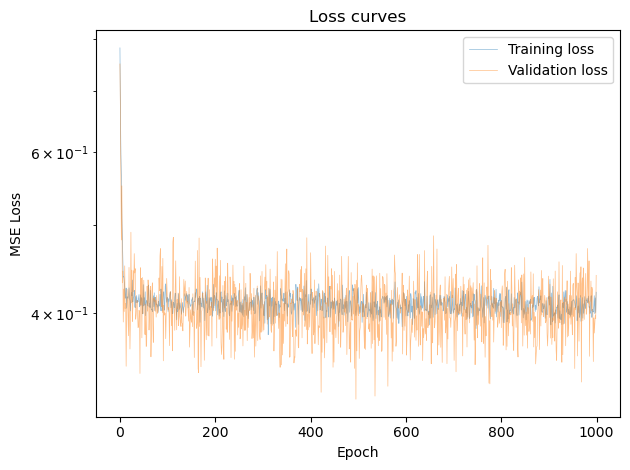

In [119]:
plt.plot(train_loss_hist,lw=0.5, alpha=0.5, label="Training loss")
plt.plot(val_loss_hist,lw=0.5,alpha=0.5,label="Validation loss")
plt.title("Loss curves")
plt.legend()
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.savefig("images/fullLossCurve.png")
plt.show()

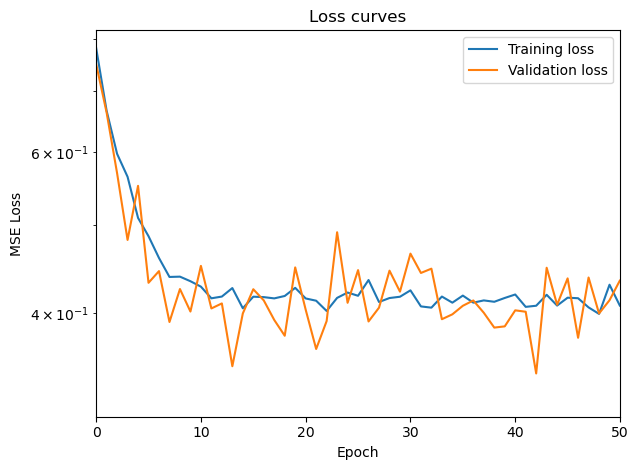

In [120]:
plt.plot(train_loss_hist, label="Training loss")
plt.plot(val_loss_hist,label="Validation loss")
plt.title("Loss curves")
plt.legend()
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.savefig("images/20_epochs_loss.png")
plt.xlim(0,50)
plt.show()

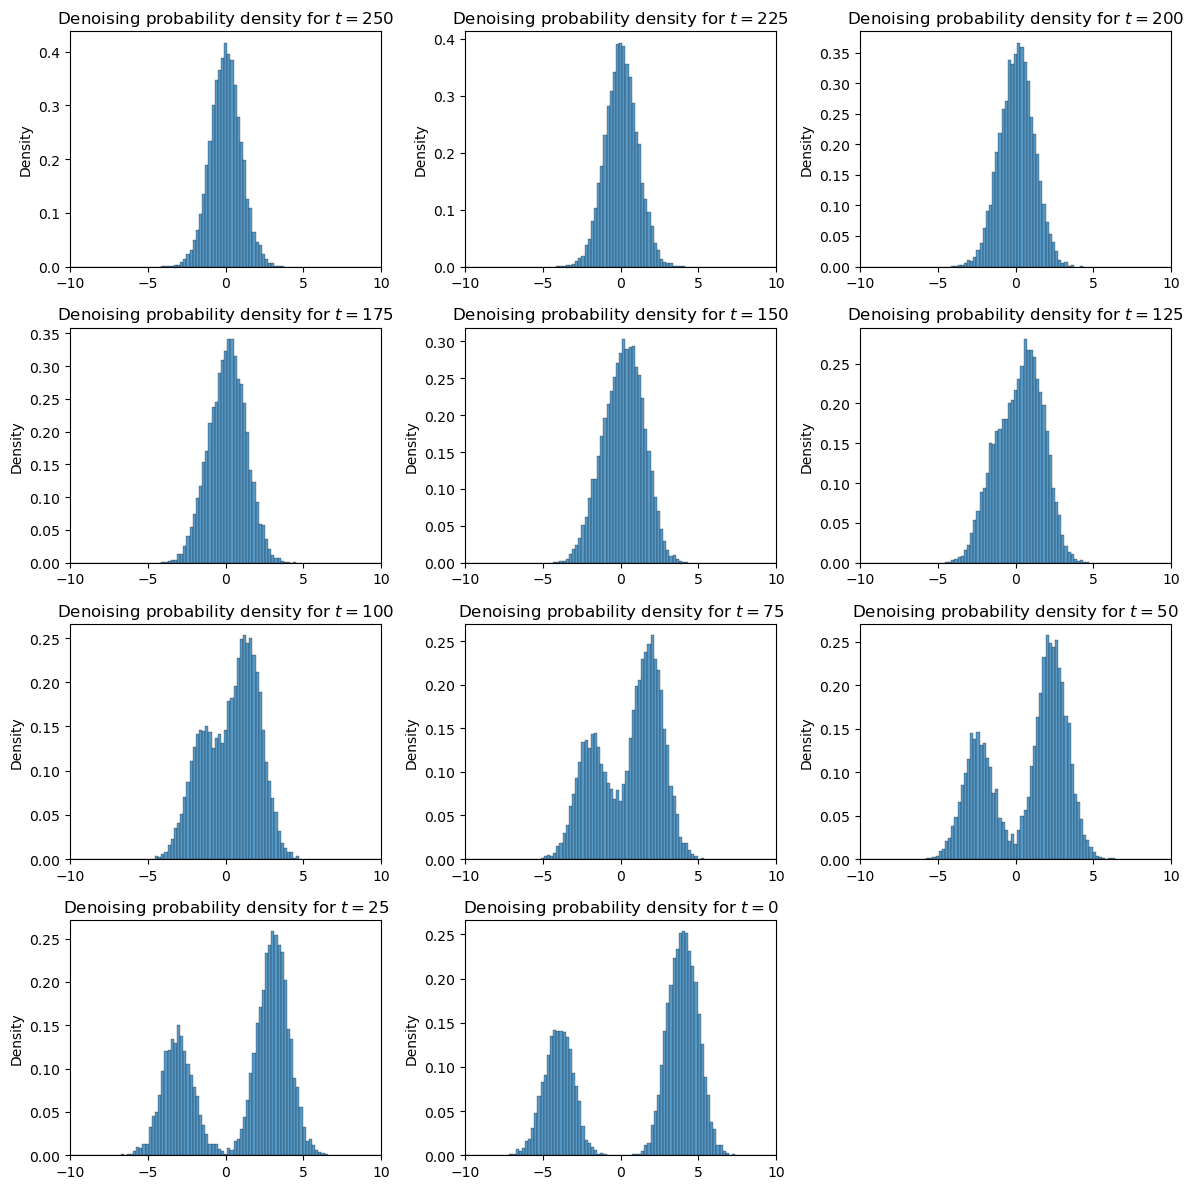

In [126]:
def sample_reverse(g, count):
    """
    Sample from the model by applying the reverse diffusion process

    Here, implement algorithm 2 of the DDPM paper (https://arxiv.org/abs/2006.11239)

    Parameters
    ----------
    g : torch.nn.Module
        The neural network that predicts the noise added to the data
    count : int
        The number of samples to generate in parallel

    Returns
    -------
    x : torch.Tensor
        The final sample from the model
    """
    g.eval()
    with torch.no_grad():
        x = torch.randn(count) # step 1
        time_evolution = [x.clone()]
        timestep = [250]
        for t in reversed(range(TIME_STEPS)): #for-loop over reversed array (step 2) 
            
            if t > 0:  # step 3; this does not follow the paper's convention as the indices start with 0, but in the paper t=1 is assumed to be the first timestep (without any noise)
                z = torch.randn_like(x)
            else:
                z = 0

            # params for x_{t-1}
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]
            beta_t = betas[t]

            t_input = torch.full((count,),t / TIME_STEPS)
            input = torch.stack([x, t_input], dim=1)
            epsilon_theta = g(input).squeeze()

            x = (1 / torch.sqrt(alpha_t)) * (x-beta_t/ torch.sqrt(1 - alpha_bar_t)* epsilon_theta) + torch.sqrt(beta_t) * z # step 4 
            if (t % 25 == 0): # return prob density every 25 timesteps
                time_evolution.append(x.clone())
                timestep.append(t)
    return x, time_evolution, timestep # step 6



##############
samples, time_evolution, timestep = sample_reverse(g, 10000)

bins = np.linspace(-10, 10, 100)
fig, axes = plt.subplots(int(np.ceil(len(time_evolution)/3)),3,figsize=(12, 3*int(np.ceil(len(time_evolution)/3))))
axes = np.array(axes).reshape(-1)
for ax, state, t in zip(axes, time_evolution, timestep):
    sns.histplot(state.numpy(),bins=bins,stat='density',ax=ax)
    ax.set_xlim(-10, 10)
    ax.set_title(rf"Denoising probability density for $t = {t}$")
    # plot probably density at different timesteps
for ax in axes[len(time_evolution):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("images/time_evolution.png")
plt.show()

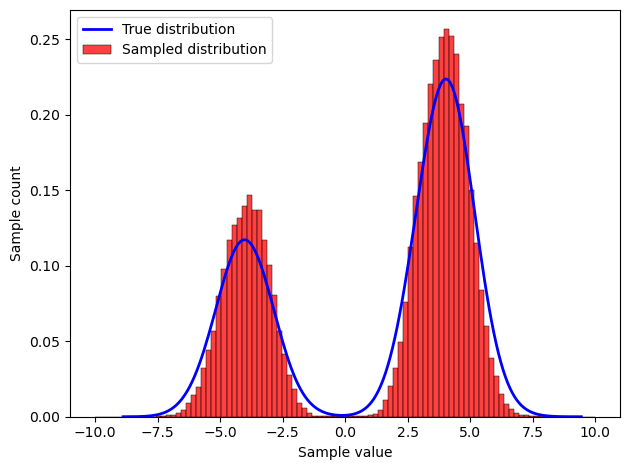

In [122]:
samples, trajectory, timestep = sample_reverse(g, 50000)
samples = samples.numpy()

# plot the samples
fig, ax = plt.subplots(1, 1)
sns.kdeplot(dataset, ax=ax, color='blue', label='True distribution', linewidth=2)
sns.histplot(samples, ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density')
ax.legend()
ax.set_xlabel('Sample value')
ax.set_ylabel('Sample count')
plt.tight_layout()
plt.savefig("images/true_vs_sampled.png")
plt.show()


Now we want to quantify the deviations between sampled  distribution and true distribution

Mean and standard deviation: Since this is not a standard gaussian, but a bimodal distribution, the following approach is not necessarily the "cleanest" approach, but we assume it's sufficient here since the peaks of sampled values seem to be well-separated.
We are going to calculate mean and standard deviation for sample values below and above $x=0$ separately.

In [123]:
print(f"Mean for x<0: {np.mean(samples[samples<=0]):.2f}\nStandard deviation for x<0: {np.std(samples[samples<=0]):.2f}\n")
print(f"Mean for x>0: {np.mean(samples[samples>0]):.2f}\nStandard deviation for x>0: {np.std(samples[samples>0]):.2f}\n")

Mean for x<0: -3.96
Standard deviation for x<0: 0.95

Mean for x>0: 3.99
Standard deviation for x>0: 0.96



The mean is reconstructed quite well, while the standard deviation is slightly underestimated.

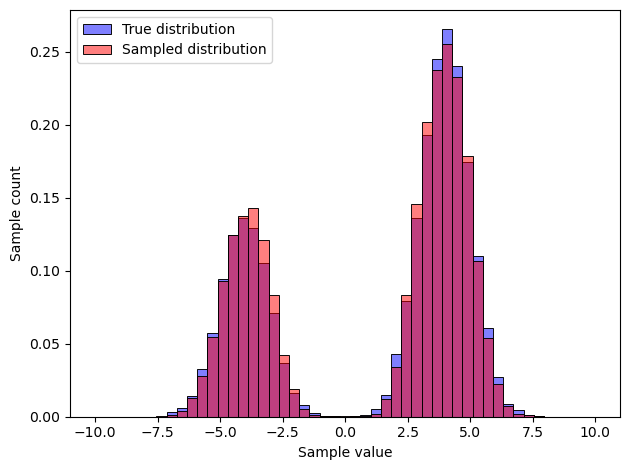

In [124]:
fig, ax = plt.subplots(1, 1)
bins = np.linspace(-10, 10, 50)
sns.histplot(dataset, ax=ax, bins=bins, color='blue', label='True distribution', stat="density", alpha=0.5)
sns.histplot(samples, ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density', alpha=0.5)
ax.legend()
ax.set_xlabel('Sample value')
ax.set_ylabel('Sample count')
plt.tight_layout()
plt.savefig("images/true_vs_sampled_hist.png")
plt.show()


Plot shows: close to the peaks the sample numbers slightly reach over the true distribution, while they remain below in the tails